In [4]:
"""
### 1. Setup & Utilities
**Aim:** Initialize environment, load API keys, and define core utility functions.
"""

import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
from deepeval.metrics import GEval, AnswerRelevancyMetric
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

# --- ENVIRONMENT ---
def setup_environment():
    load_dotenv(find_dotenv()) 
    if "OPENAI_API_KEY" not in os.environ:
        print("⚠️ WARNING: OPENAI_API_KEY not found. Metrics will fail.")
    else:
        print("✅ Environment loaded.")

# --- DATA CLEANING ---
def clean_id(col):
    """Robust cleaning for IDs/Phone Numbers."""
    return col.astype(str).str.replace(r'\.0$', '', regex=True).str.strip()


def preprocess_text(text):
    """Normalizes text (lowercase, remove emojis, strip spaces)."""
    if not isinstance(text, str): text = str(text)
    text = text.lower()
    emoji_pattern = re.compile("[" "\U0001f600-\U0001f64f" "\U0001f300-\U0001f5ff" "\U0001f680-\U0001f6ff" "\U0001f1e0-\U0001f1ff" "\U00002702-\U000027b0" "\U000024c2-\U0001f251" "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r"", text).strip()
    return re.sub(r"\s+", " ", text)

# --- LOADING RESOURCES ---
def load_flow_definitions(json_dir):
    definitions = {}
    path = Path(json_dir)
    if not path.exists(): return definitions
    for jf in path.glob("*.json"):
        try:
            with jf.open("r", encoding="utf-8") as f:
                data = json.load(f)
                if isinstance(data, dict):
                    for k, v in data.items():
                        definitions[k] = v
        except:
            pass
    return definitions


def load_strata_mapping(strata_file, id_map_file):
    print("Loading Strata Mapping...")

    try:
        df_strata = pd.read_csv(strata_file)
        df_ids = pd.read_csv(id_map_file)
        
        # Clean Keys
        df_strata['msisdn'] = clean_id(df_strata['msisdn'])
        df_ids['msisdn'] = clean_id(df_ids['msisdn'])
        df_ids['contact_id'] = clean_id(df_ids['contact_id'])
        
        # Join
        merged = pd.merge(df_ids, df_strata, on='msisdn', how='inner')
        print(f"   > Matched {len(merged)} IDs to Demographics.")
        return merged[['contact_id', 'age_group', 'gestation_group']]

    except Exception as e:
        print(f"⚠️ Error loading strata: {e}")
        return pd.DataFrame()


def enrich_with_strata(df, strata_path, id_map_path):
    if df.empty: return df
    if 'contact_id' not in df.columns:
        return df

    strata_map = load_strata_mapping(strata_path, id_map_path)
    if strata_map.empty:
        return df
    
    df['contact_id'] = clean_id(df['contact_id'])
    # Prevent duplicate columns
    df = df.drop(columns=[c for c in ['age_group', 'gestation_group'] if c in df.columns])
    
    df = pd.merge(df, strata_map, on='contact_id', how='left')
    print(f"✅ Enriched Results. Rows with Age Group: {df['age_group'].notna().sum()}")
    return df


def find_reference_question(definitions, flow_group, question_key):
    KEY_ALIASES = {
        "dma-pre-assessment": "dma-assessment", "dma-post-assessment": "dma-assessment",
        "knowledge-pre-assessment": "knowledge-assessment", "knowledge-post-assessment": "knowledge-assessment",
        "attitude-pre-assessment": "attitude-assessment", "attitude-post-assessment": "attitude-assessment",
        "behaviour-pre-assessment": "behaviour-pre-assessment", "behaviour-post-assessment": "behaviour-post-assessment"
    }
    clean_key = str(question_key).lstrip('@')
    if clean_key.endswith('_text'): clean_key = clean_key[:-5]
    clean_key_lower = clean_key.lower()

    # Strategy A
    search_scope = [definitions.get(flow_group, []), definitions.get('anc-survey', []), definitions.get('onboarding', [])]
    for node_list in search_scope:
        if isinstance(node_list, list):
            for node in node_list:
                ids = [str(node.get(k,'')) for k in ['collects','question_name','title','id']]
                if any(i.lower() == clean_key_lower for i in ids): return node.get('content')

    # Strategy B
    match = re.match(r"(.+)-(\d+)$", clean_key)
    if match:
        name, idx_str = match.groups()
        json_name = KEY_ALIASES.get(name, name)
        try:
            idx = int(idx_str) - 1
            if json_name in definitions:
                return definitions[json_name][idx].get('content')
        except:
            pass
    return None


setup_environment()

✅ Environment loaded.


In [5]:
"""
### 2. Configuration
**Aim:** Define file paths and run settings.
"""

# --- FILE PATHS ---
PROD_FILE = "data/stratified_prod_data_20251201.csv"
JSON_DIR = "../../static_content/"
STRATA_FILE = "data/oai_sample_with_strata.csv"
ID_MAP_FILE = "data/oai_sampled_user_ids.csv"

# --- OUTPUT PATHS ---
VERIFIED_FILE = "data/prod_data_verified.csv"
FINAL_REPORT = "data/evaluation_results.csv"

# --- RUN SETTINGS ---
# Set integer (e.g. 5) to sample rows per Question. None = Full Run.
SAMPLE_SIZE = 5

# Set True to force new LLM calls. False loads existing CSV (but updates strata).
RERUN_EVALUATION = False
# -------------------------

print(f"Config Loaded. Target: {PROD_FILE}")

Config Loaded. Target: data/stratified_prod_data_20251201.csv



--- STEP 1: AUGMENTING DATA ---
✅ Verified Data Saved: data/prod_data_verified.csv

--- STEP 2: EVALUATION ---
ℹ️ Loading cached results from data/evaluation_results.csv...
Loading Strata Mapping...
   > Matched 4 IDs to Demographics.
✅ Enriched Results. Rows with Age Group: 47

📊 FINAL EXECUTIVE SUMMARY (N=242)

► GLOBAL PERFORMANCE:
                  Metric  Score
     Extraction Accuracy 83.88%
    Question Consistency 69.03%
Response Appropriateness 87.19%

► PERFORMANCE BY FLOW MODULE:


,Accuracy,Consistency,Appropriateness
flow,,,
anc,94.2%,68.5%,75.0%
dma,44.0%,69.7%,100.0%
kab,83.1%,64.3%,86.9%
onboarding,100.0%,84.8%,97.1%



► PERFORMANCE BY AGE GROUP:


,Accuracy,Consistency,Appropriateness
age_group,,,
18-24,95.7%,70.9%,87.0%
35+,100.0%,80.2%,100.0%



► PERFORMANCE BY GESTATION STAGE:


,Accuracy,Consistency,Appropriateness
gestation_group,,,
14-27 weeks,100.0%,80.2%,100.0%
28+ weeks,95.7%,70.9%,87.0%


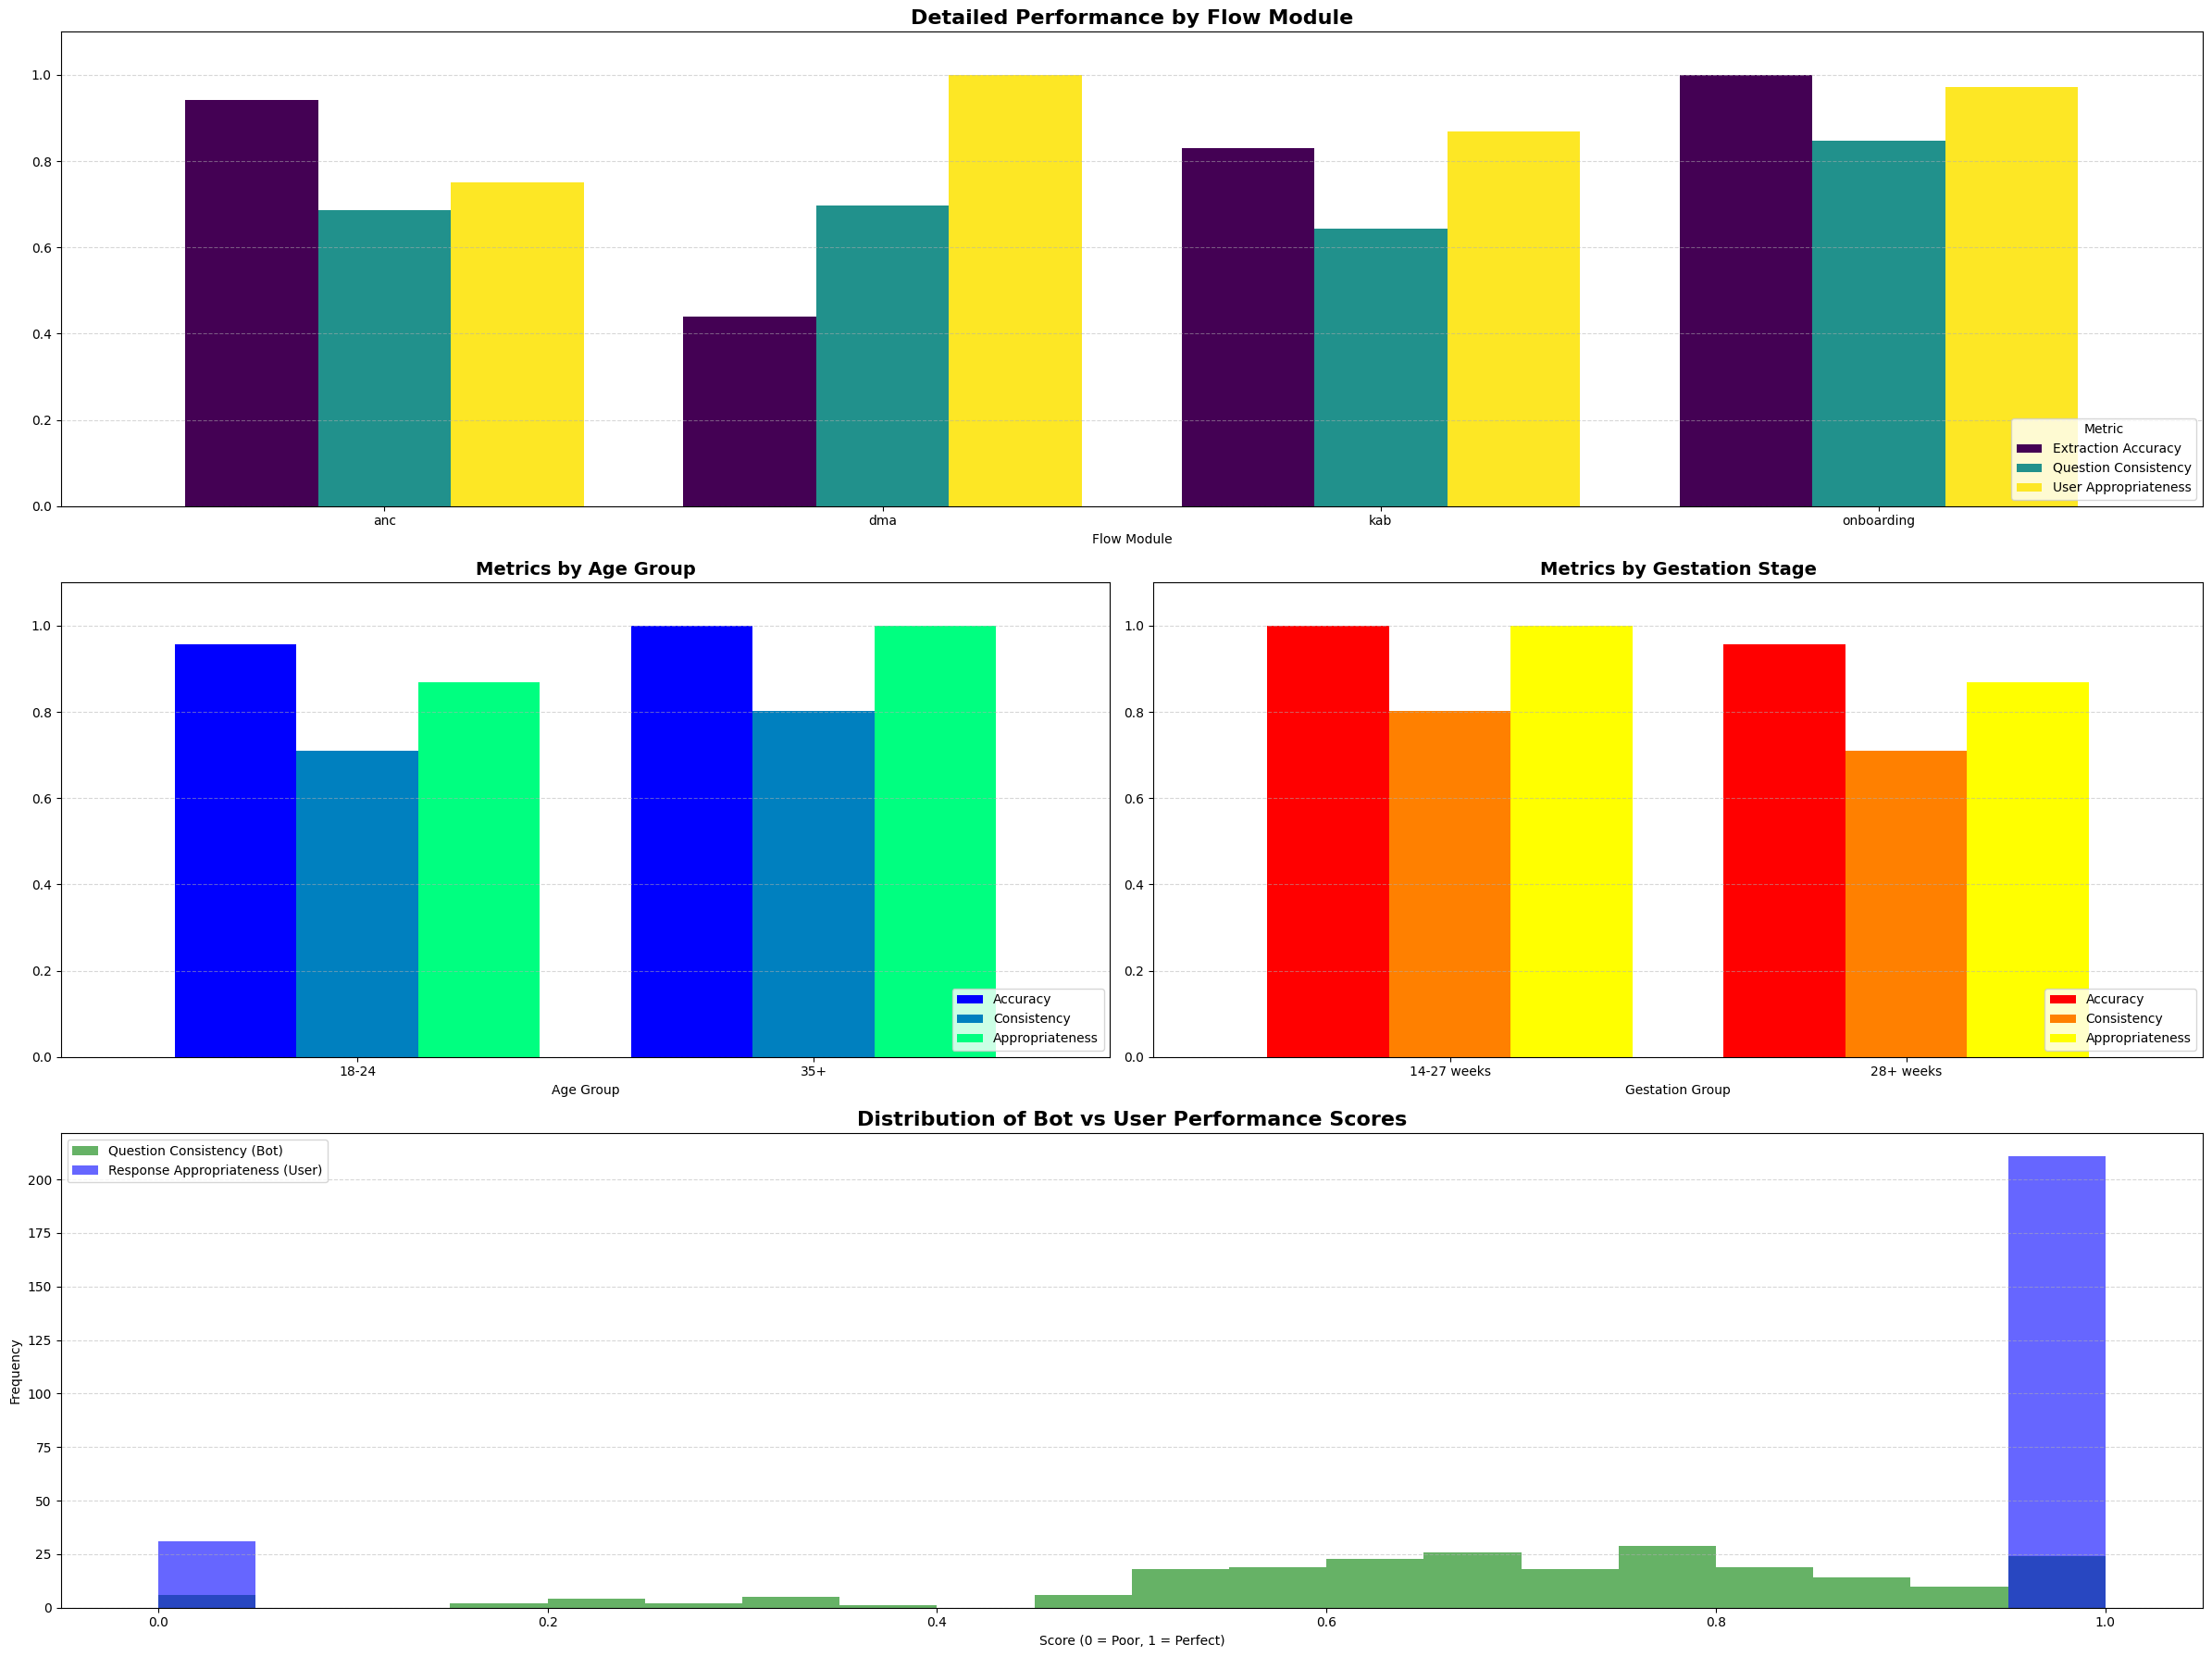

In [ ]:
"""
### 3. Pipeline Execution
**Aim:** Runs the full evaluation pipeline:
1. Augment (Map Questions)
2. Evaluate (LLM Judges + Strata Enrichment)
3. Visualize (Matplotlib Plots & Reports)
"""

# ==========================================
# STEP 1: AUGMENT DATA
# ==========================================

def step_1_augment():
    print(f"\n--- STEP 1: AUGMENTING DATA ---")
    try:
        df = pd.read_csv(PROD_FILE)
        if 'question_key' not in df.columns:
            df = pd.read_csv(PROD_FILE, header=1)
    except Exception as e:
        print(f"❌ Error reading CSV: {e}")
        return pd.DataFrame()

    definitions = load_flow_definitions(JSON_DIR)
    df['flow_lower'] = df['flow_group'].astype(str).str.lower()
    df['reference_question'] = df.apply(lambda row: find_reference_question(definitions, row['flow_lower'], row.get('question_key', '')) or "MISSING_REF", axis=1)
    df.drop(columns=['flow_lower'], inplace=True)
    
    df.to_csv(VERIFIED_FILE, index=False)
    print(f"✅ Verified Data Saved: {VERIFIED_FILE}")
    
    return df


# ==========================================
# STEP 2: RUN EVALUATION
# ==========================================
def step_2_evaluate(df):
    print(f"\n--- STEP 2: EVALUATION ---")
    
    # LOAD CACHE IF EXISTS
    if not RERUN_EVALUATION and os.path.exists(FINAL_REPORT):
        print(f"ℹ️ Loading cached results from {FINAL_REPORT}...")
        res_df = pd.read_csv(FINAL_REPORT)
        # Re-enrich to ensure strata is up to date
        return enrich_with_strata(res_df, STRATA_FILE, ID_MAP_FILE)

    # INIT METRICS
    print("Initializing LLM Judges (GPT-4o)...")
    consistency_metric = GEval(name="Consistency", criteria="ACTUAL vs EXPECTED meaning match", evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT], model="gpt-4o")
    relevancy_metric = AnswerRelevancyMetric(threshold=0.7, model="gpt-4o", include_reason=True)

    # FILTER 'OTHER' & SAMPLE
    # Robust case-insensitive filter
    df_clean = df[df['flow_group'].astype(str).str.lower() != 'other'].copy()
    print(f"   > Filtered out 'other' flows. Remaining: {len(df_clean)}")

    if SAMPLE_SIZE:
        print(f"⚠️ TEST MODE: Sampling {SAMPLE_SIZE} rows per Question Key...")
        eval_df = df_clean.groupby(['flow_group', 'question_key']).head(SAMPLE_SIZE).copy()
        eval_df = eval_df.sample(frac=1, random_state=42).reset_index(drop=True)

    else:
        print(f"🚀 FULL MODE: Evaluating {len(df_clean)} rows.")
        eval_df = df_clean.copy()

    results = []
    for idx, row in eval_df.iterrows():
        if idx % 10 == 0: print(f"Processing row {idx}...")
        
        actual_q = str(row.get('llm_question_text', ''))
        ref_q = str(row.get('reference_question', ''))
        user_ans = str(row.get('user_answer_raw', ''))
        sys_map = preprocess_text(row.get('user_answer_mapped', ''))
        human_map = preprocess_text(row.get('user_answer_mapped_by_human', ''))

        if not human_map or human_map in ['nan', 'tba', '']:
            continue

        # Metric 1: Accuracy
        is_accurate = (sys_map == human_map)

        # Metric 2: Consistency
        cons_score, cons_reason = None, "N/A"
        if ref_q not in ["MISSING_REF", "nan", ""]:
            try:
                tc = LLMTestCase(input="Check", actual_output=actual_q, expected_output=ref_q)
                consistency_metric.measure(tc)
                cons_score, cons_reason = consistency_metric.score, consistency_metric.reason
            except:
                pass

        # Metric 3: Appropriateness
        app_score, app_reason = None, "N/A"
        if actual_q and user_ans and user_ans != "nan":
            try:
                tc = LLMTestCase(input=actual_q, actual_output=user_ans)
                relevancy_metric.measure(tc)
                app_score, app_reason = relevancy_metric.score, relevancy_metric.reason
            except:
                pass

        results.append({
            "contact_id": row.get('contact_id'), "flow": row.get('flow_group'), "key": row.get('question_key'),
            "llm_question": actual_q, "ref_question": ref_q, "user_input": user_ans,
            "extraction_correct": is_accurate, "consistency_score": cons_score, "appropriateness_score": app_score,
            "sys_map": sys_map, "human_map": human_map, "consistency_reason": cons_reason, "appropriateness_reason": app_reason
        })

    res_df = pd.DataFrame(results)
    res_df = enrich_with_strata(res_df, STRATA_FILE, ID_MAP_FILE)
    res_df.to_csv(FINAL_REPORT, index=False)
    print(f"✅ Saved results to {FINAL_REPORT}")
    return res_df


# ==========================================
# STEP 3: VISUALIZE (Matplotlib Only)
# ==========================================
def step_3_visualize(res_df):
    if res_df.empty:
        return

    # --- 1. EXECUTIVE SUMMARY TABLES ---
    print("\n" + "="*60)
    print(f"📊 FINAL EXECUTIVE SUMMARY (N={len(res_df)})")
    print("="*60)
    
    # Global Metrics Table
    global_metrics = pd.DataFrame({
        'Metric': ['Extraction Accuracy', 'Question Consistency', 'Response Appropriateness'],
        'Score': [
            res_df['extraction_correct'].mean(),
            res_df['consistency_score'].mean(),
            res_df['appropriateness_score'].mean()
        ]
    })
    
    # Display Global Metrics
    print("\n► GLOBAL PERFORMANCE:")
    print(global_metrics.to_string(index=False, formatters={'Score': '{:.2%}'.format}))

    # Flow Performance Table
    print("\n► PERFORMANCE BY FLOW MODULE:")
    flow_stats = res_df.groupby('flow')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
    flow_stats.columns = ['Accuracy', 'Consistency', 'Appropriateness']
    display(flow_stats.style.format("{:.1%}").background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

    # Demographic Tables (if data exists)
    if 'age_group' in res_df.columns:
        print("\n► PERFORMANCE BY AGE GROUP:")
        age_stats = res_df.groupby('age_group')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
        age_stats.columns = ['Accuracy', 'Consistency', 'Appropriateness']
        display(age_stats.style.format("{:.1%}").background_gradient(cmap='Blues'))

    if 'gestation_group' in res_df.columns:
        print("\n► PERFORMANCE BY GESTATION STAGE:")
        gest_stats = res_df.groupby('gestation_group')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
        gest_stats.columns = ['Accuracy', 'Consistency', 'Appropriateness']
        display(gest_stats.style.format("{:.1%}").background_gradient(cmap='Purples'))


    # --- 2. VISUALIZATIONS ---
    fig = plt.figure(figsize=(24, 18))
    plt.subplots_adjust(hspace=0.4)

    # PLOT 1: Performance by Flow (Multi-Metric)
    ax1 = plt.subplot(3, 1, 1)
    flow_plot_data = res_df.groupby('flow')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
    flow_plot_data.columns = ['Extraction Accuracy', 'Question Consistency', 'User Appropriateness']
    
    # Use Pandas plotting (wraps Matplotlib) for grouped bars
    flow_plot_data.plot(kind='bar', ax=ax1, width=0.8, colormap='viridis')
    
    ax1.set_title('Detailed Performance by Flow Module', fontsize=16, fontweight='bold')
    ax1.set_ylim(0, 1.1)
    ax1.legend(loc='lower right', title='Metric')
    ax1.set_xlabel('Flow Module')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    plt.setp(ax1.get_xticklabels(), rotation=0)


    # PLOT 2: Performance by Age (Multi-Metric)
    ax2 = plt.subplot(3, 2, 3)
    if 'age_group' in res_df.columns:
        age_plot_data = res_df.groupby('age_group')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
        age_plot_data.columns = ['Accuracy', 'Consistency', 'Appropriateness']
        
        age_plot_data.plot(kind='bar', ax=ax2, width=0.8, colormap='winter')
        ax2.set_title('Metrics by Age Group', fontsize=14, fontweight='bold')
        ax2.set_ylim(0, 1.1)
        ax2.legend(loc='lower right')
        ax2.set_xlabel('Age Group')
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        plt.setp(ax2.get_xticklabels(), rotation=0)
    else:
        ax2.text(0.5, 0.5, "No Age Data", ha='center')


    # PLOT 3: Performance by Gestation (Multi-Metric)
    ax3 = plt.subplot(3, 2, 4)
    if 'gestation_group' in res_df.columns:
        gest_plot_data = res_df.groupby('gestation_group')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
        gest_plot_data.columns = ['Accuracy', 'Consistency', 'Appropriateness']
        
        gest_plot_data.plot(kind='bar', ax=ax3, width=0.8, colormap='autumn')
        ax3.set_title('Metrics by Gestation Stage', fontsize=14, fontweight='bold')
        ax3.set_ylim(0, 1.1)
        ax3.legend(loc='lower right')
        ax3.set_xlabel('Gestation Group')
        ax3.grid(axis='y', linestyle='--', alpha=0.5)
        plt.setp(ax3.get_xticklabels(), rotation=0)
    else:
        ax3.text(0.5, 0.5, "No Gestation Data", ha='center')


    # PLOT 4: Metric Distributions (Consistency vs Appropriateness)
    ax4 = plt.subplot(3, 1, 3)
    cons_data = res_df['consistency_score'].dropna()
    app_data = res_df['appropriateness_score'].dropna()
    
    ax4.hist(cons_data, bins=20, range=(0,1), alpha=0.6, label='Question Consistency (Bot)', color='green')
    ax4.hist(app_data, bins=20, range=(0,1), alpha=0.6, label='Response Appropriateness (User)', color='blue')
    
    ax4.set_title('Distribution of Bot vs User Performance Scores', fontsize=16, fontweight='bold')
    ax4.set_xlabel('Score (0 = Poor, 1 = Perfect)')
    ax4.set_ylabel('Frequency')
    ax4.legend()
    ax4.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- EXECUTE PIPELINE ---
if __name__ == "__main__":
    df_ver = step_1_augment()
    if not df_ver.empty:
        df_res = step_2_evaluate(df_ver)
        step_3_visualize(df_res)
